# **Dataset Exploration**

In [40]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, accuracy_score, classification_report
from scipy.special import expit

In [3]:
# Load the dataset
df = pd.read_csv('heart.csv')

In [4]:
# Show the first few rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# Show the last few rows of the dataset
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
# Define the shape of the dataset
df.shape

(1025, 14)

In [7]:
# Analyze numerical features
numerical_features = df.select_dtypes(include=['number'])
numerical_features.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# Check for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# Check for duplicated values
df.duplicated().sum()

np.int64(723)

In [10]:
# Examine the data types
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


# **Exploratory Data Analysis**

In [11]:
# Identify categorical features
categorical_features = df.select_dtypes(include=['object', 'category'])
print("Categorical Features:")
print(categorical_features.columns)

Categorical Features:
Index([], dtype='object')


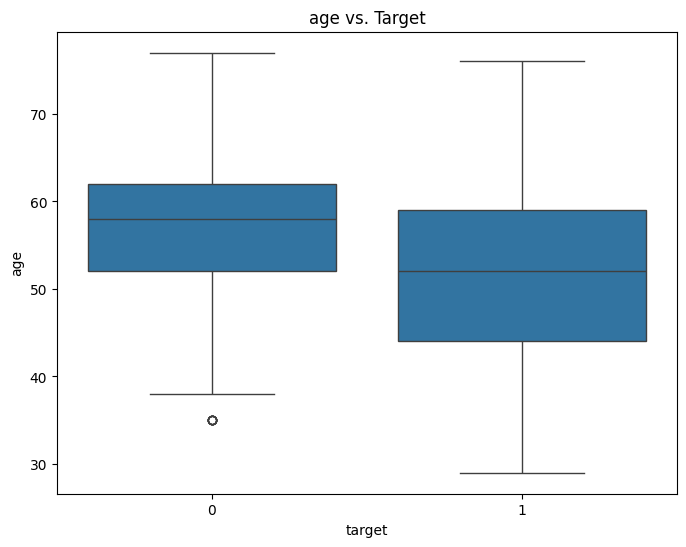

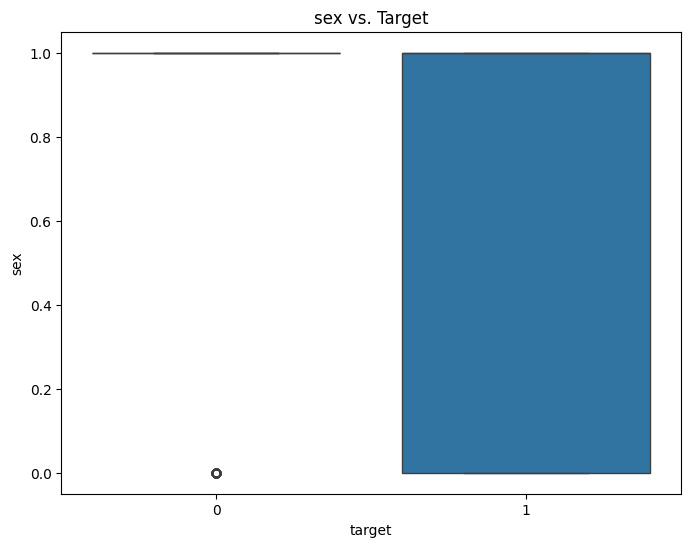

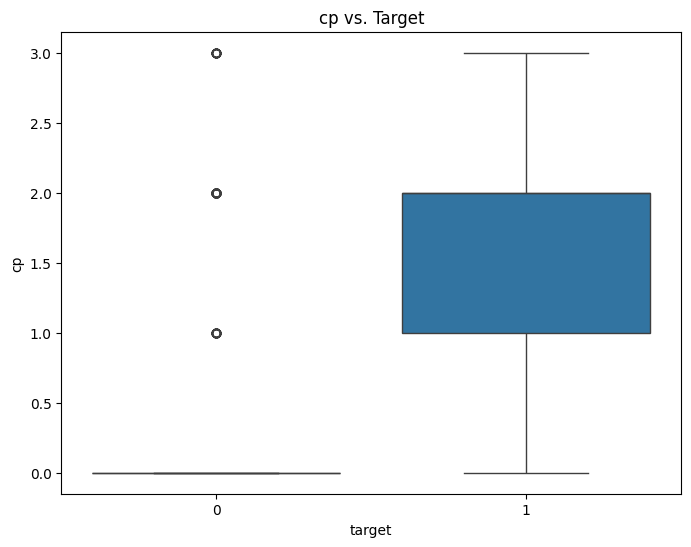

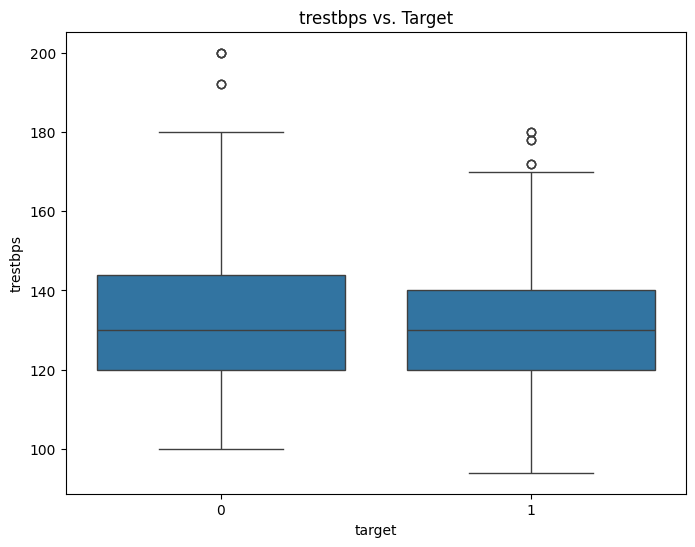

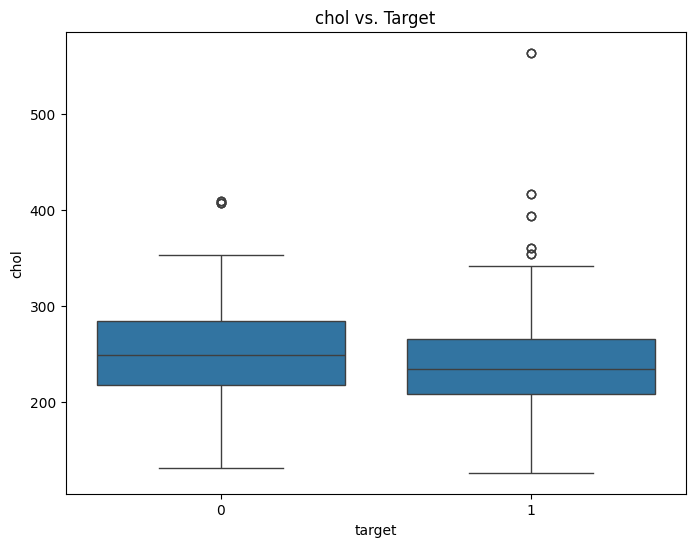

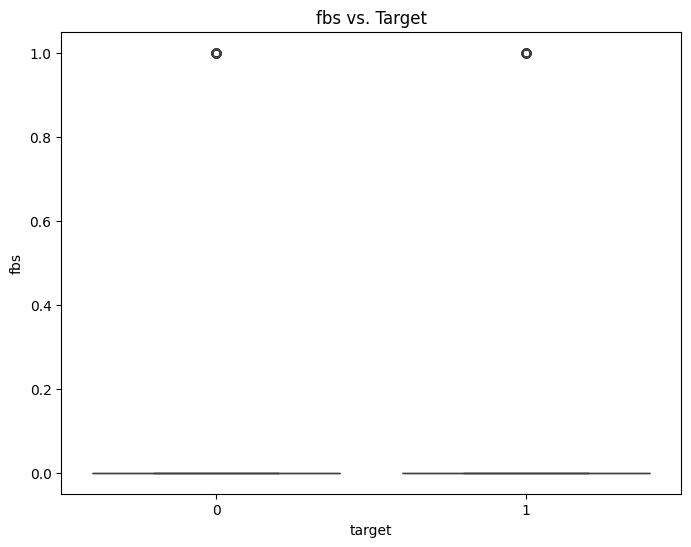

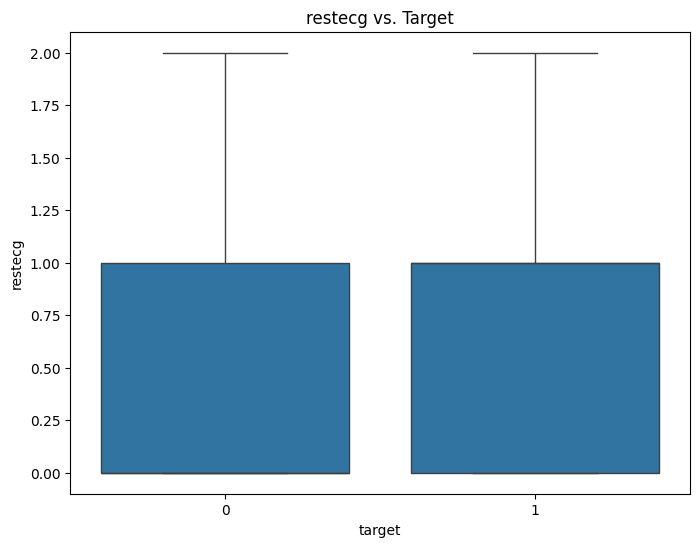

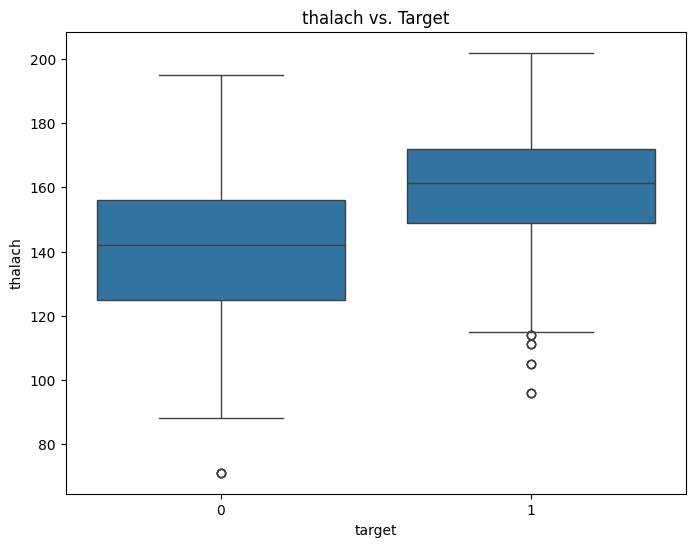

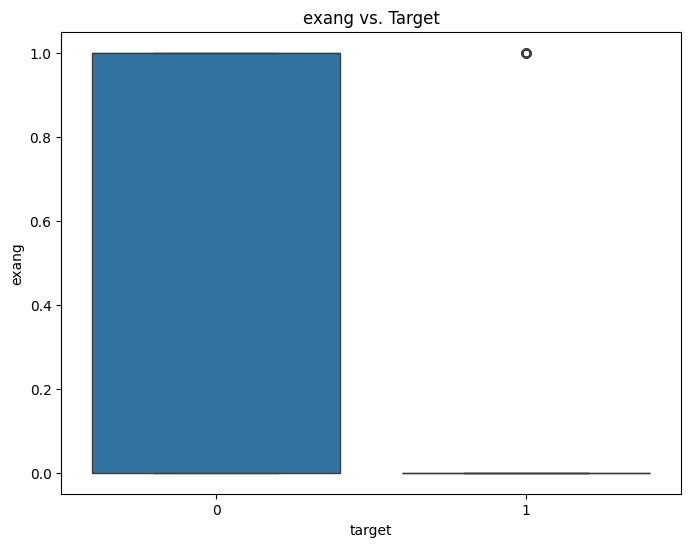

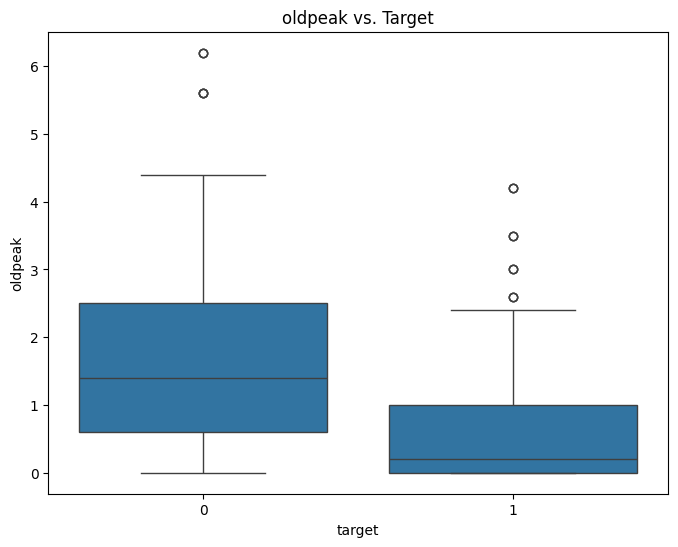

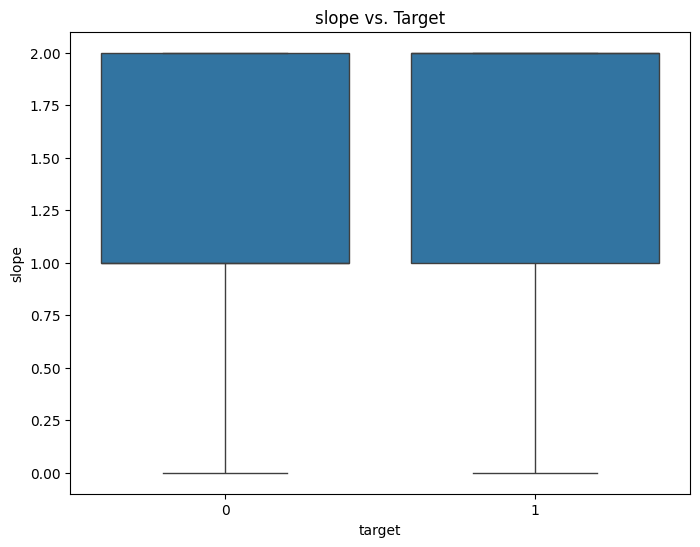

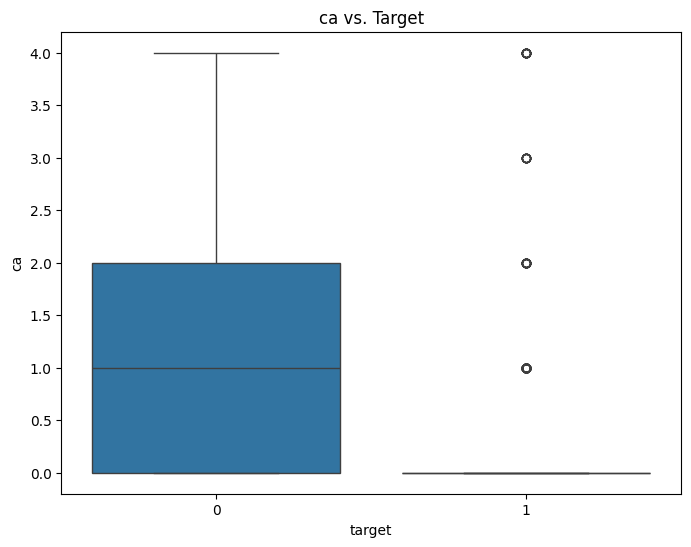

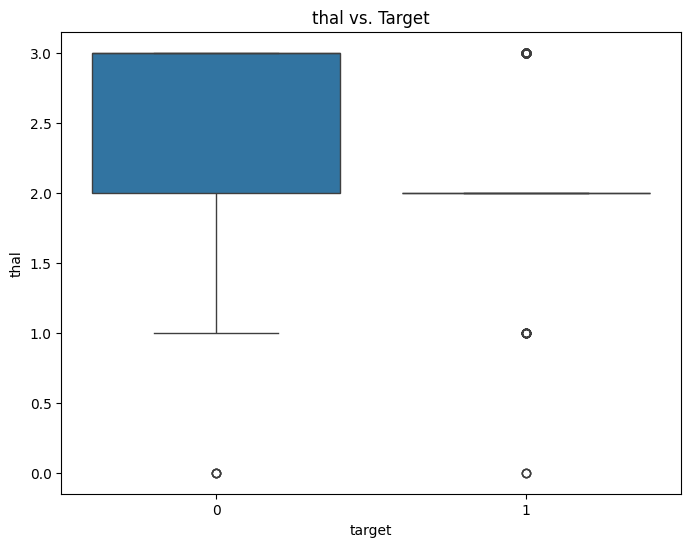

In [14]:
# Relationship between numerical features and target
numerical_features = df.select_dtypes(include=['number']).columns
numerical_features = numerical_features.drop('target') # Exclude target from this loop

for col in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='target', y=col)
    plt.title(f'{col} vs. Target')
    plt.show()

<Figure size 2000x1700 with 0 Axes>

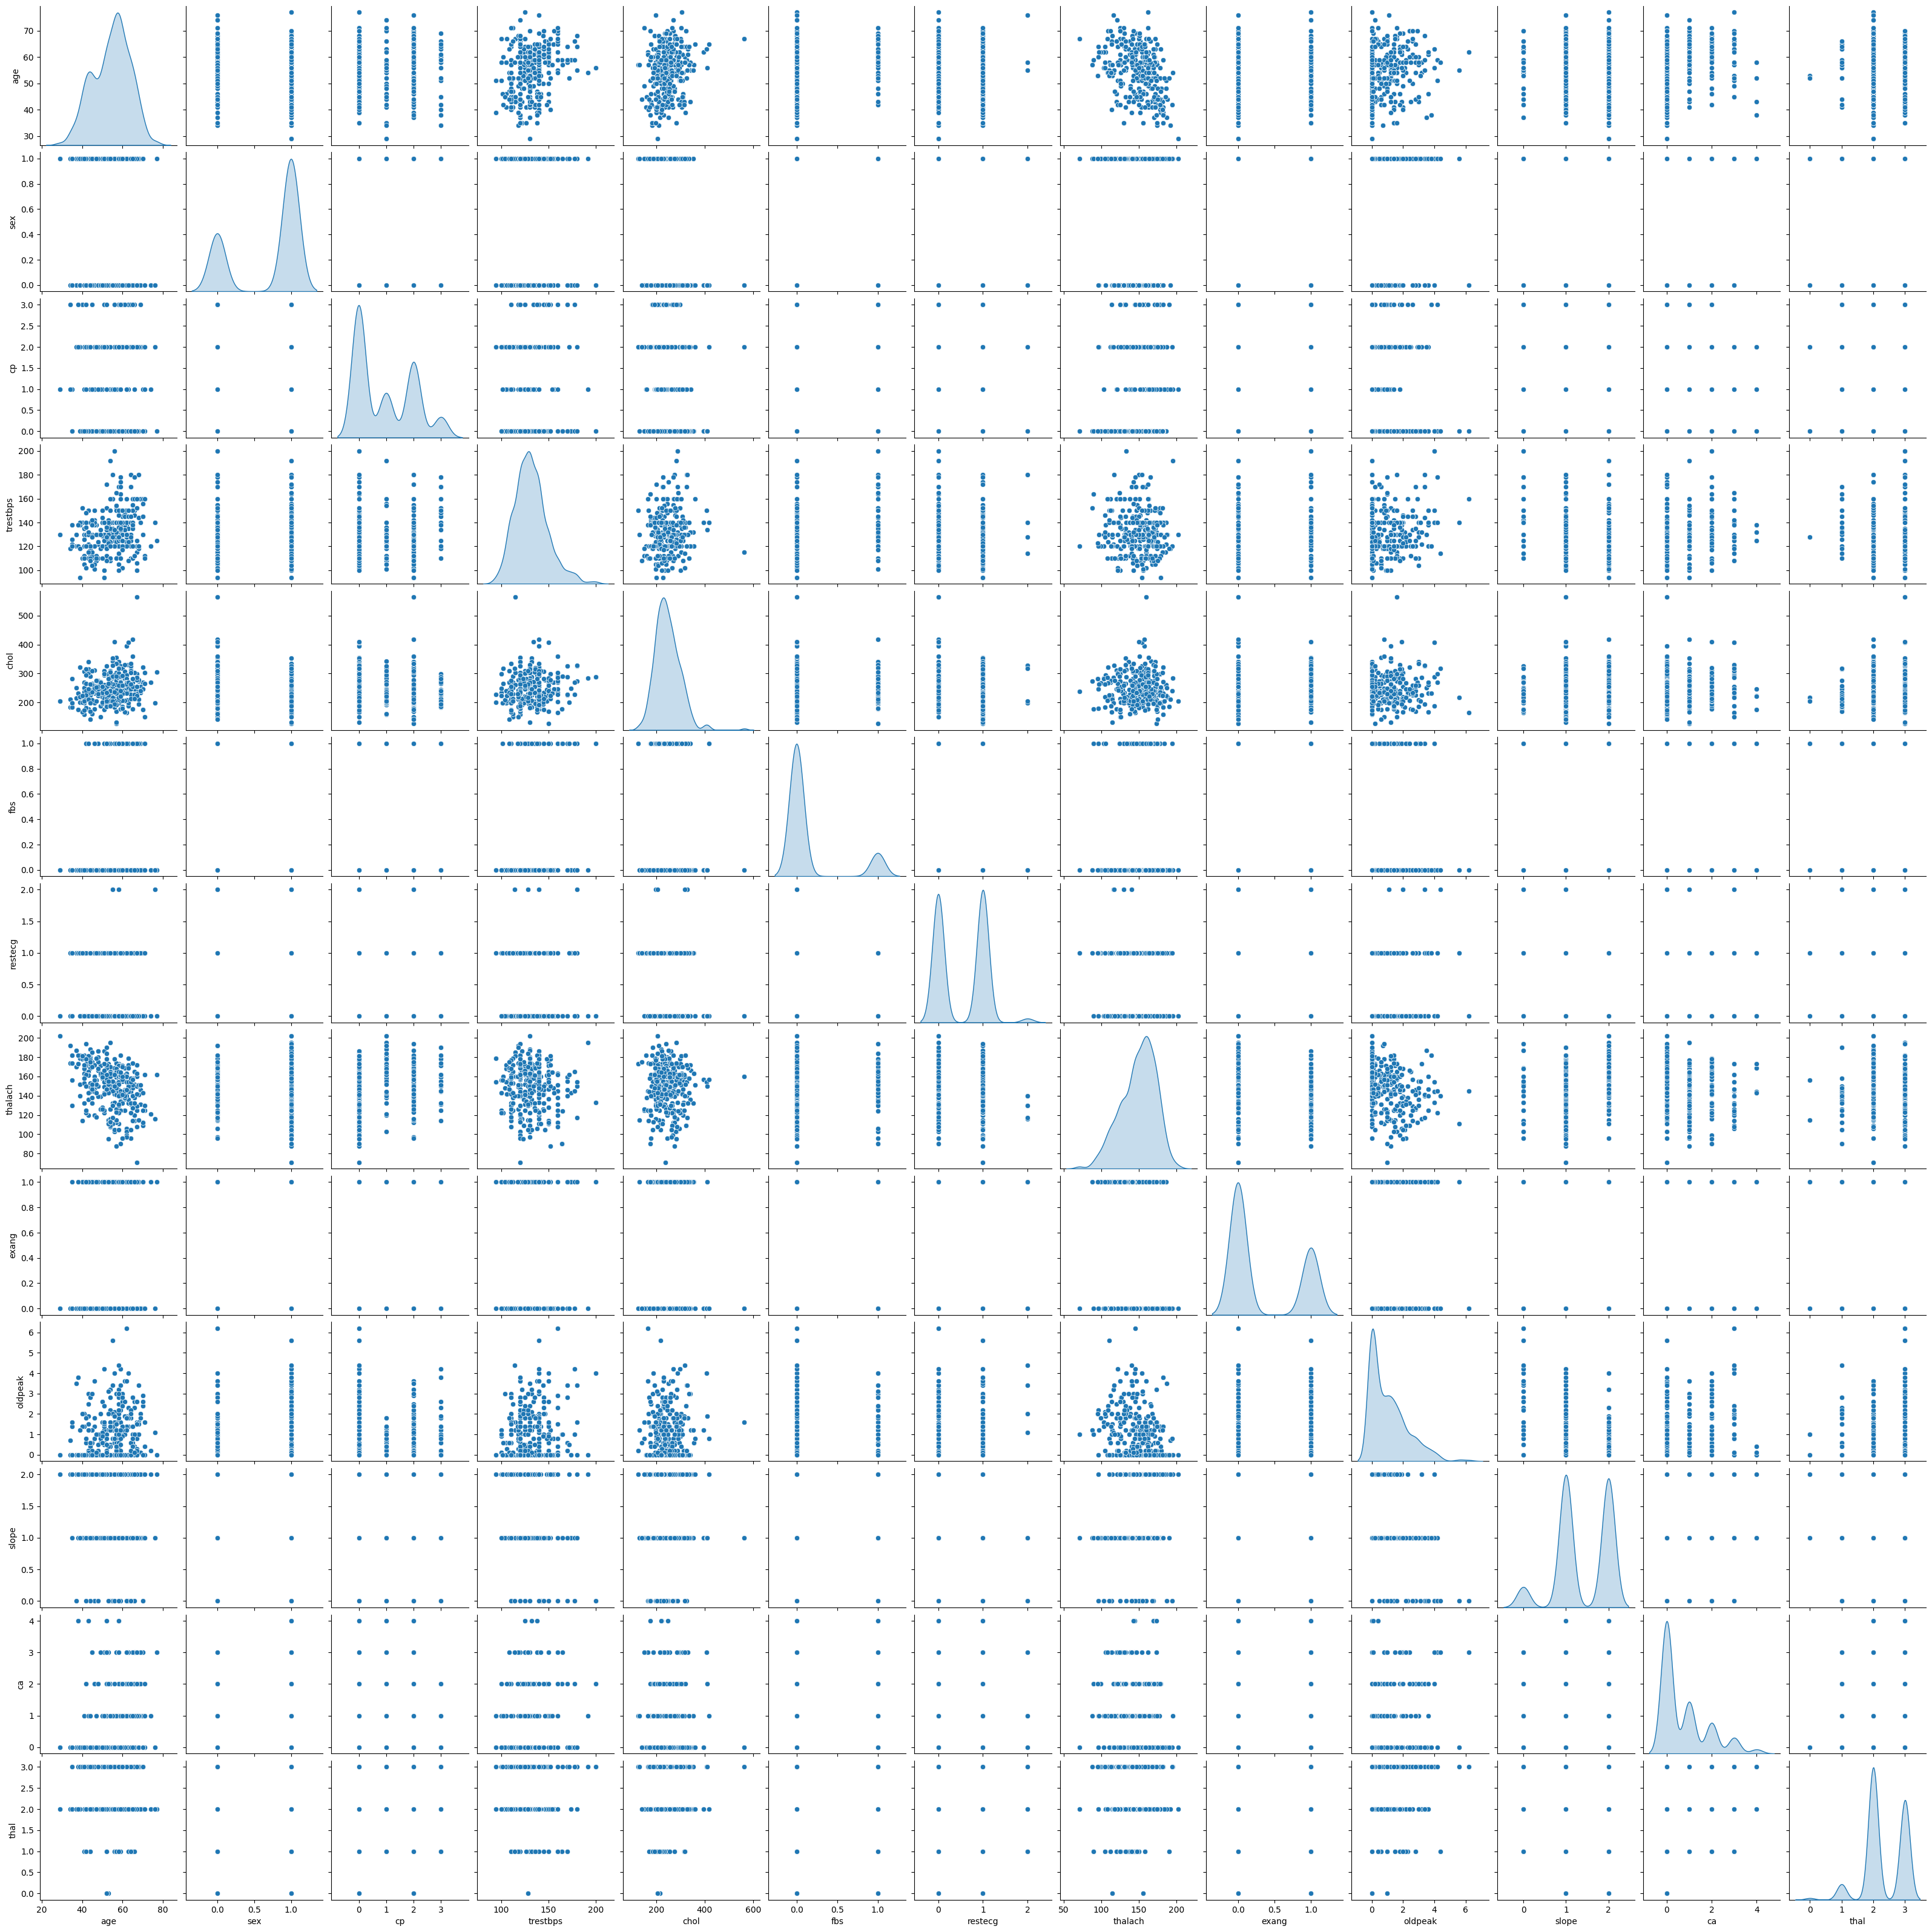

In [19]:
# Pairwise relationships between numerical features
plt.figure(figsize=(20, 17))
sns.pairplot(df[numerical_features], diag_kind='kde')
plt.show()


Correlation with target variable:
 age        -0.229324
sex        -0.279501
cp          0.434854
trestbps   -0.138772
chol       -0.099966
fbs        -0.041164
restecg     0.134468
thalach     0.422895
exang      -0.438029
oldpeak    -0.438441
slope       0.345512
ca         -0.382085
thal       -0.337838
target      1.000000
Name: target, dtype: float64


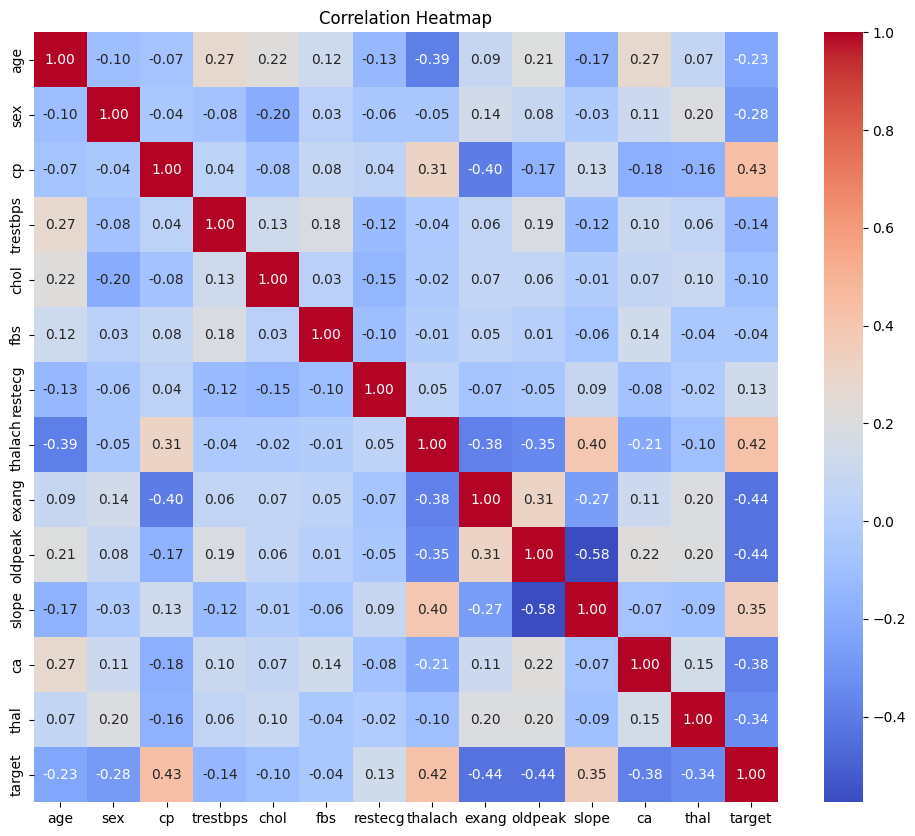

In [21]:
# Correlation with target variable
correlations = df.corr()['target']
print("\nCorrelation with target variable:\n", correlations)

import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

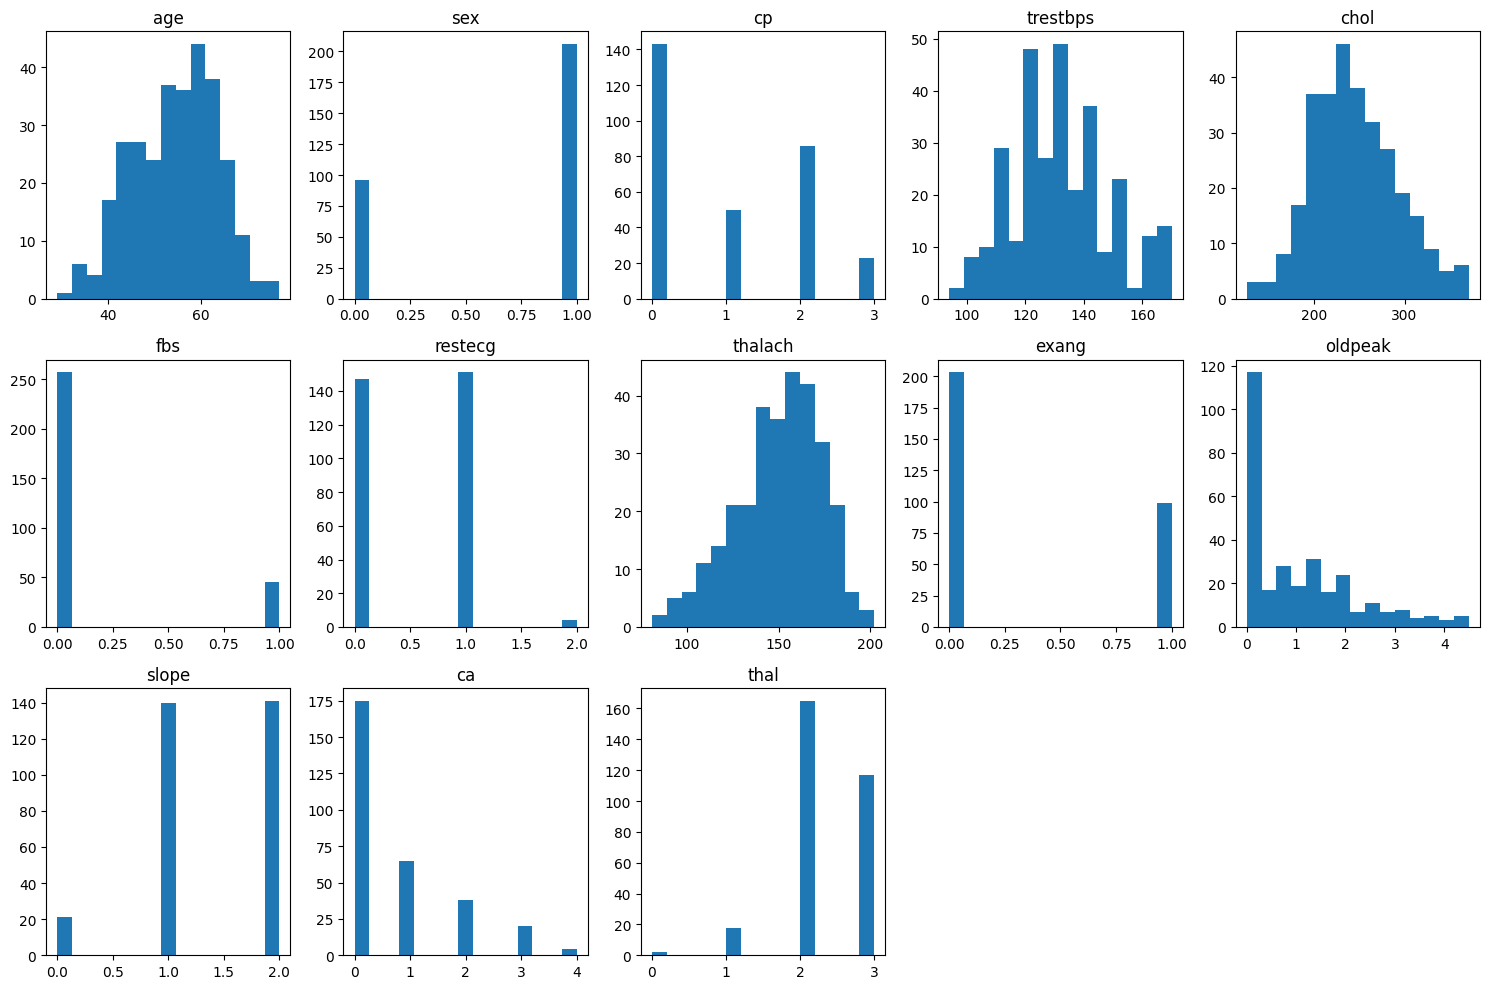

In [25]:
# Histograms for numerical features
plt.figure(figsize=(15, 10))

# Redefine numerical_features to include all numerical columns except 'target'
numerical_features = df.select_dtypes(include=['number']).columns
numerical_features = numerical_features.drop('target')

for i, col in enumerate(numerical_features):
    plt.subplot(3, 5, i + 1)
    plt.hist(df[col], bins=15)  # Adjust bins as needed
    plt.title(col)
plt.tight_layout()
plt.show()

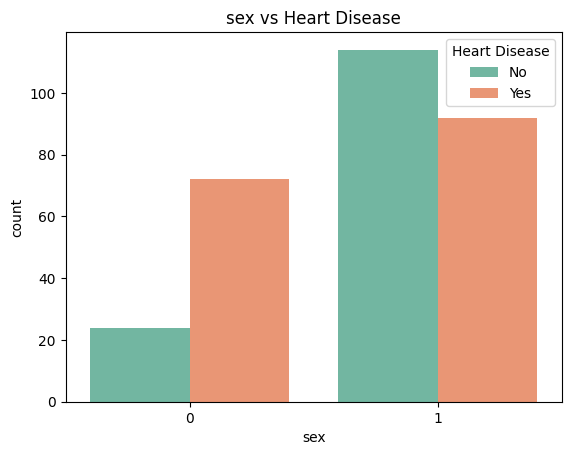

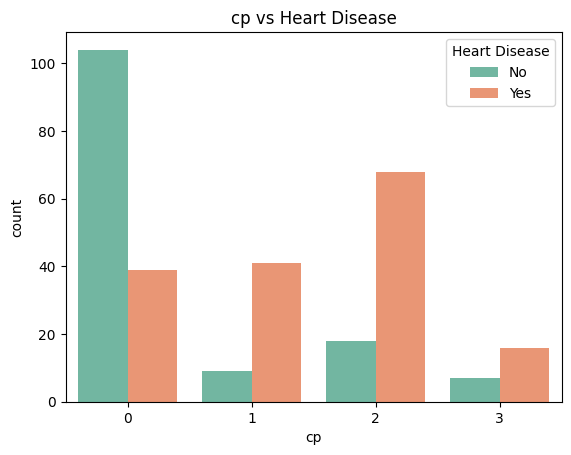

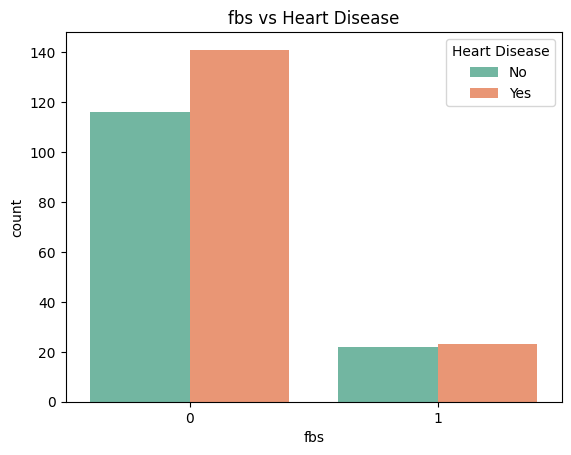

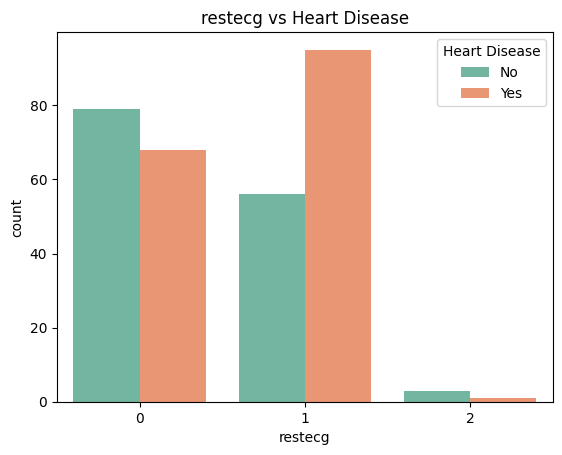

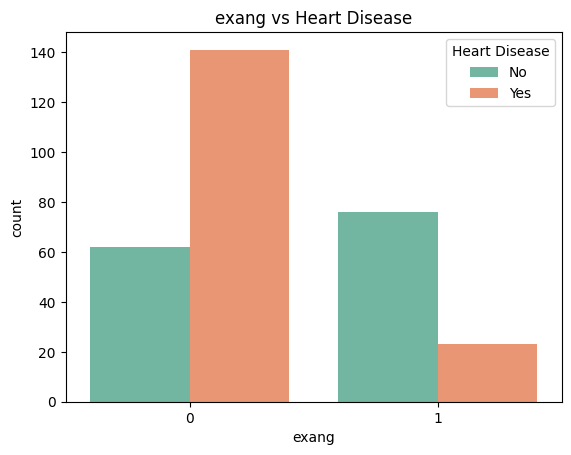

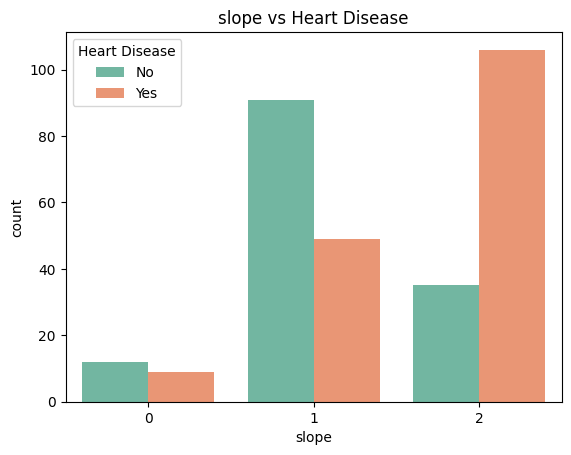

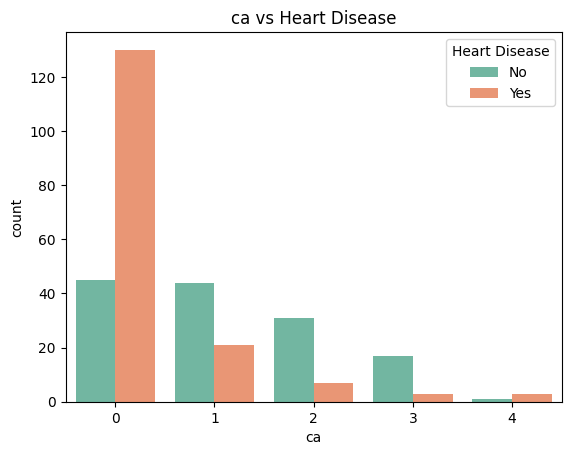

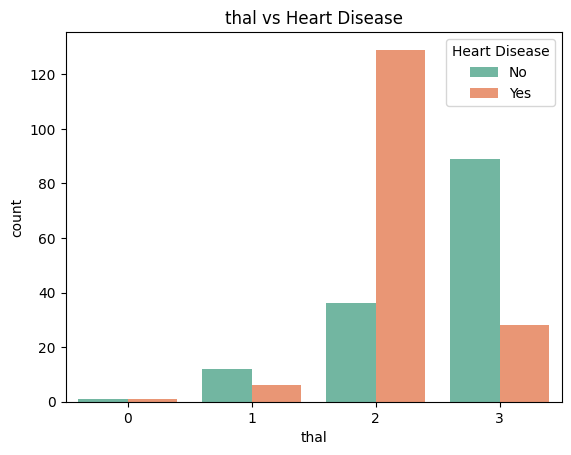

In [27]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in categorical_cols:
    sns.countplot(x=col, hue='target', data=df, palette='Set2')
    plt.title(f'{col} vs Heart Disease')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
    plt.show()

In [28]:
# Outlier handling using IQR-based capping
numerical_features = ['chol', 'trestbps', 'thalach', 'oldpeak']
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Duplicate removal
duplicate_rows = df[df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Number of duplicate rows: {num_duplicates}")
df = df.drop_duplicates()
print(f"Shape of DataFrame after removing duplicates: {df.shape}")
display(df.head())

Number of duplicate rows: 0
Shape of DataFrame after removing duplicates: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53,1,0,140,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62,0,0,138,294.0,1,1,106.0,0,1.9,1,3,2,0


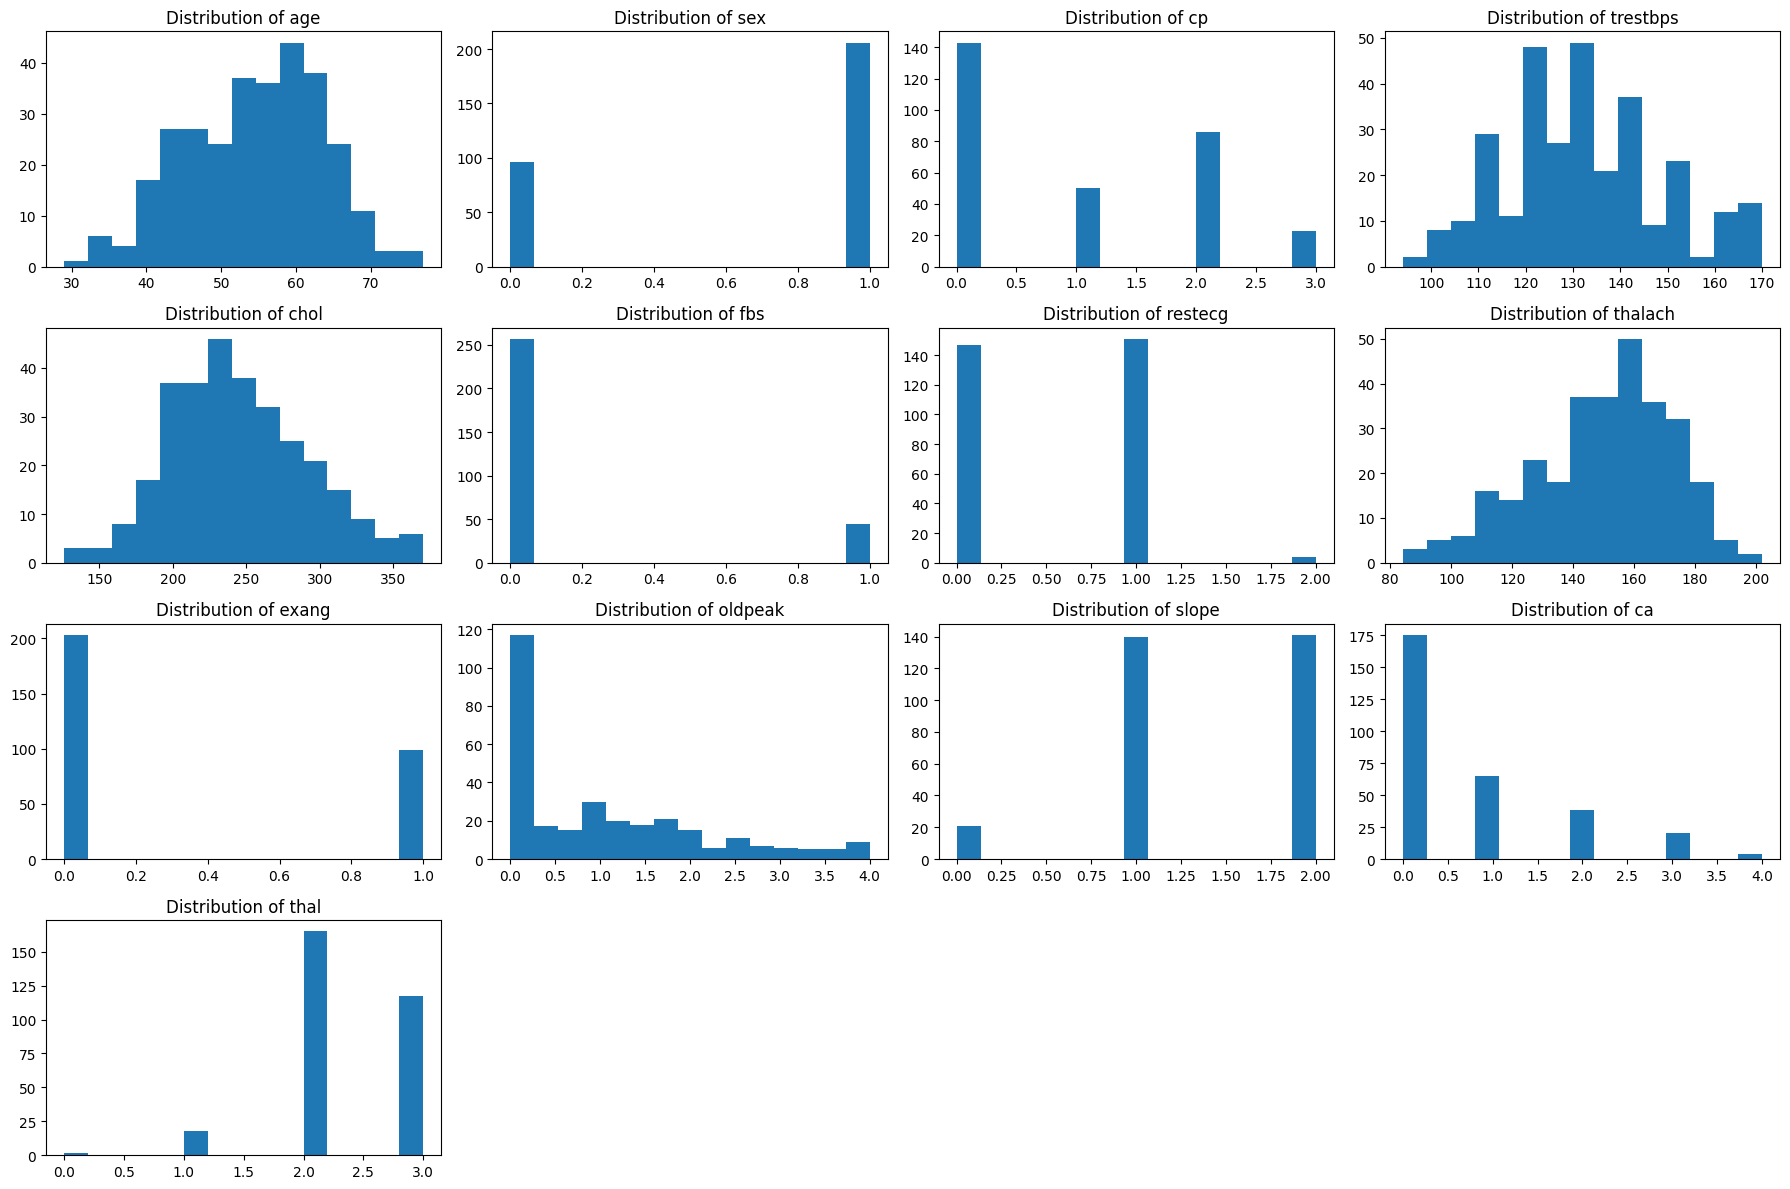

In [29]:
# Re-examine distributions of numerical features after cleaning
numerical_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1)
    plt.hist(df[col], bins=15)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# **Model Training, Optimization And Evaluatation**

In [30]:
# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data into training (70%), validation (15%), and testing (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print the shapes of the resulting datasets to verify the split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (211, 13)
y_train shape: (211,)
X_val shape: (45, 13)
y_val shape: (45,)
X_test shape: (46, 13)
y_test shape: (46,)


In [31]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train)

# Transform training, validation, and test sets
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [44]:
# Initialize RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)

# Initialize RFE
n_features_to_select = 8
rfe = RFE(estimator=rfc, n_features_to_select=n_features_to_select)

# Fit RFE to the training data
rfe.fit(X_train, y_train)

# Apply feature selection to training, validation, and test sets using boolean indexing
X_train_selected = X_train[:, rfe.support_]
X_val_selected = X_val[:, rfe.support_]
X_test_selected = X_test[:, rfe.support_]

In [45]:
# Gradient Boosting Classifier

# Initialize a dictionary to store ROC curve data for different models
roc_data = {}

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

print("Gradient Boosting Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_data['Gradient Boosting'] = (fpr_gb, tpr_gb, roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Classifier Results:
Accuracy: 0.6956521739130435
F1 Score: 0.6818181818181818
AUC-ROC: 0.8495238095238095
              precision    recall  f1-score   support

           0       0.63      0.81      0.71        21
           1       0.79      0.60      0.68        25

    accuracy                           0.70        46
   macro avg       0.71      0.70      0.70        46
weighted avg       0.72      0.70      0.69        46



In [46]:
# Support Vector Machine Classifier
svc = SVC(probability=True, random_state=42)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)
y_prob_svc = svc.predict_proba(X_test)[:, 1]

print("SVM Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_svc))
print(classification_report(y_test, y_pred_svc))

fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
roc_data['SVM'] = (fpr_svc, tpr_svc, roc_auc_score(y_test, y_prob_svc))

SVM Classifier Results:
Accuracy: 0.7608695652173914
F1 Score: 0.7555555555555555
AUC-ROC: 0.8533333333333333
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        21
           1       0.85      0.68      0.76        25

    accuracy                           0.76        46
   macro avg       0.77      0.77      0.76        46
weighted avg       0.78      0.76      0.76        46



In [48]:
# Neural Network Classifier
nn_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
nn_clf.fit(X_train, y_train)

y_pred_nn = nn_clf.predict(X_test)
y_prob_nn = nn_clf.predict_proba(X_test)[:, 1]

print("Neural Network Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("F1 Score:", f1_score(y_test, y_pred_nn))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_nn))
print(classification_report(y_test, y_pred_nn))

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
roc_data['Neural Network'] = (fpr_nn, tpr_nn, roc_auc_score(y_test, y_prob_nn))


Neural Network Classifier Results:
Accuracy: 0.7608695652173914
F1 Score: 0.7555555555555555
AUC-ROC: 0.8419047619047619
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        21
           1       0.85      0.68      0.76        25

    accuracy                           0.76        46
   macro avg       0.77      0.77      0.76        46
weighted avg       0.78      0.76      0.76        46



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


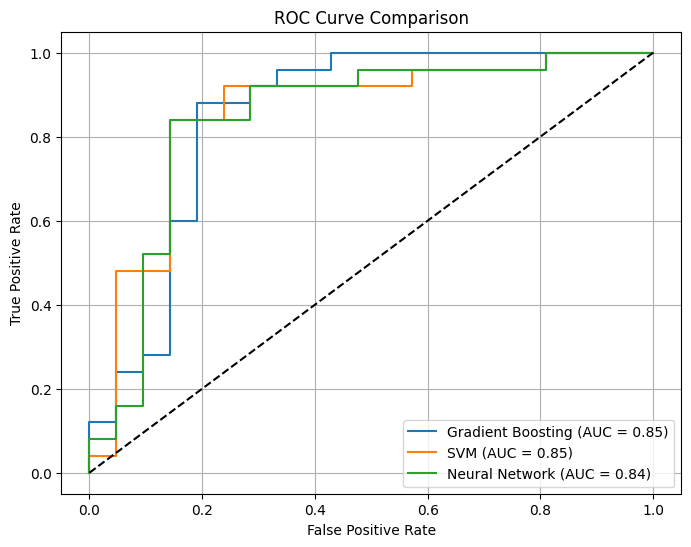

In [49]:
# Plot all ROC Curves
plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

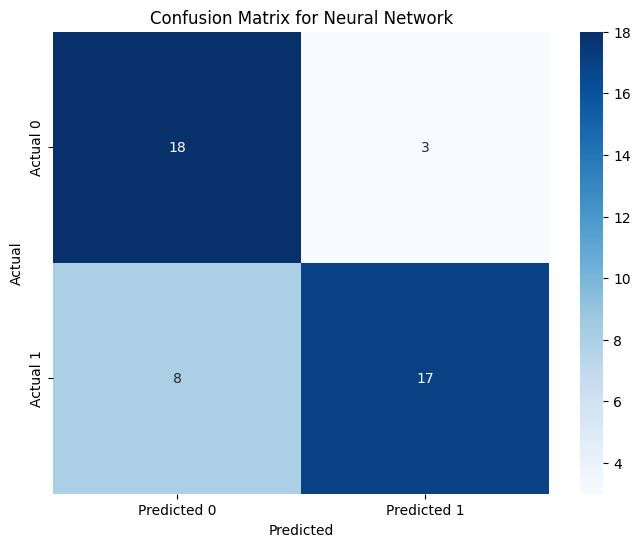

In [55]:
# Calculate the confusion matrix using the defined best_model and the full test set X_test
cm = confusion_matrix(y_test, nn_clf.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for Neural Network')
plt.show()

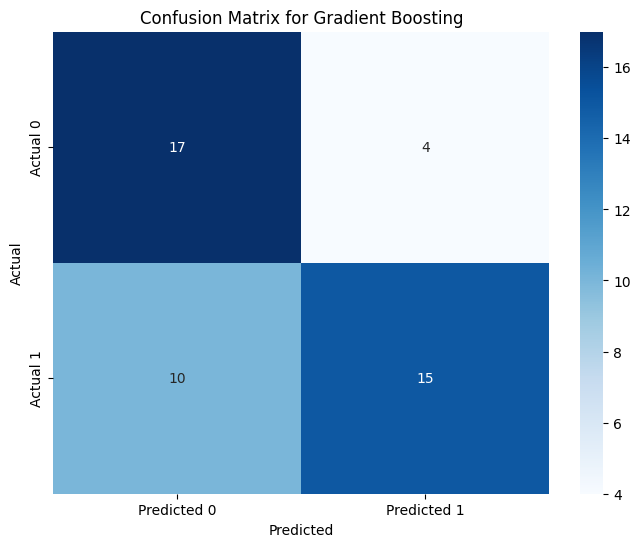

In [56]:
# Calculate the confusion matrix for the Gradient Boosting Classifier
cm_gb = confusion_matrix(y_test, gb_clf.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

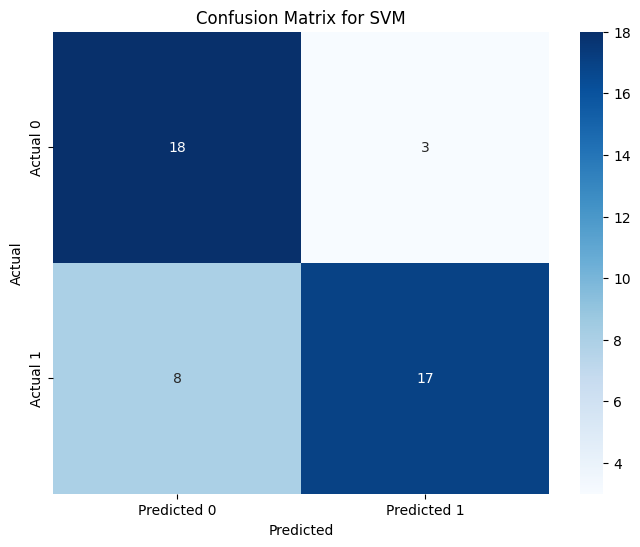

In [57]:
# Calculate the confusion matrix for the Support Vector Machine Classifier
cm_svc = confusion_matrix(y_test, svc.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()

# **Insights**

# -> Predictive models can help pinpoint individuals with an increased risk of heart disease.

# -> Models support early identification for timely interventions to prevent or delay heart disease.

# -> Predictions can aid in efficiently distributing healthcare resources to patients at higher risk.

# -> Understanding individual risk factors from models allows for customized treatment and lifestyle advice.

# -> Utilizing predictive analytics can lead to better-informed decisions and potentially enhanced patient health.

# -> Models provide additional insights for clinicians to complement their expertise.